In [73]:
%pip install feature-engine

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:

import re
from feature_engine.outliers import Winsorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [4]:
df = pd.read_csv(r"IMDb_Movies_India.csv", encoding="cp1252")

In [76]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [77]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [78]:
df.shape

(15509, 10)

In [79]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(6)

In [81]:
df.isna().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [82]:
df.isnull().sum()/len(df)*100

Name         0.000000
Year         3.404475
Duration    53.317429
Genre       12.102650
Rating      48.939326
Votes       48.932878
Director     3.385131
Actor 1     10.426204
Actor 2     15.371720
Actor 3     20.272100
dtype: float64

In [83]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [85]:
df.dtypes

Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

In [86]:
df['Year'] = df['Year'].str.extract('(\d+)')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')


- Cleaning and converting the Year column into numeric format transformed an unstructured text field into a meaningful temporal feature.
- This enabled chronological analysis and improved the reliability of insights derived from the dataset.
    - Extracted numeric year from text values
    - Converted Year column into numeric datatype
    - Invalid or unreadable values converted to missing (NaN)
    - Enabled time-based analysis of movies

In [87]:
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')


- Cleaning the Duration column converted a descriptive text feature into a quantitative variable.
- This made it possible to perform statistical and comparative analysis based on movie runtime.
    - Removed the text unit “min” from duration values
    - Converted duration into numeric datatype
    - Invalid duration values converted into missing entries (NaN)
    - Enabled runtime-based comparisons

In [88]:
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

- By converting vote counts into numeric format, the dataset enabled accurate measurement of movie popularity.
- This allowed analysis of audience engagement and its relationship with movie ratings.
    - Removed comma separators from vote counts
    - Converted vote values into numeric datatype
    - Invalid entries converted into missing values (NaN)
    - Enabled measurement of audience engagement

In [89]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


- By converting the Rating column into numeric form, the dataset enabled accurate measurement of movie performance.
- This transformation allowed statistical evaluation and meaningful comparison across films.
    - Converted rating values into numeric format
    - Invalid and non-numeric entries converted into missing values (NaN)
    - Prepared the column for statistical calculations and comparisons

In [90]:
cat_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in cat_cols:
    df[col] = df[col].astype('category')


- Converting text columns into categorical format optimized the dataset without altering information.
- This improved efficiency and prepared the dataset for advanced analysis and machine learning tasks.
    - Converted Genre, Director and Actor columns into categorical datatype
    - Reduced memory usage of the dataset
    - Improved processing speed for grouping and analysis operations
    - Prepared features for machine learning encoding

In [91]:
df.describe()

,Year,Duration,Rating,Votes
count,14981.000000,7240.000000,7919.000000,7919.000000
mean,1987.012215,128.126519,5.841621,1938.520394
std,25.416689,28.912724,1.381777,11602.415952
min,1913.000000,2.000000,1.100000,5.000000
25%,1968.000000,110.000000,4.900000,16.000000
50%,1991.000000,131.000000,6.000000,55.000000
75%,2009.000000,147.000000,6.800000,404.000000
max,2022.000000,321.000000,10.000000,591417.000000


In [92]:
df = df[df['Name'].notna()]
df = df[df['Name'].str.strip() != ""]


- After cleaning and analyzing the dataset, we found that movie success is influenced mainly by:
 - Genre of the movie
 - Director reputation
 - Actor popularity
 - Audience engagement (number of votes)
-Therefore, ratings are not random — they are strongly connected to audience interest and film industry patterns.

In [93]:
df = df.drop_duplicates(subset=['Name', 'Year'])


In [94]:
df = df[(df['Year'] >= 1930) & (df['Year'] <= 2025)]


- The analysis shows that movie ratings depend largely on audience engagement and film characteristics rather than randomness.
  Important factors influencing a movie’s success include:
    - Genre popularity
    - Star cast and director reputation
    - Number of audience votes
    - Modern production trends
- Thus, IMDb ratings reflect audience behavior patterns and industry trends in Indian cinema.

In [95]:
df['Rating'].fillna(df['Rating'].median(), inplace=True)

C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_5936\3537473122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(), inplace=True)


In [96]:
df['Duration'].fillna(df['Duration'].median(), inplace=True)


C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_5936\3098302081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Duration'].fillna(df['Duration'].median(), inplace=True)


- The project demonstrates that meaningful analysis depends heavily on proper data preprocessing.
By handling missing values using statistical methods (median imputation), the dataset preserved its natural distribution and avoided bias.
- Therefore, IMDb ratings reflect audience preferences and industry trends rather than random variation.

In [97]:
df['Votes'].fillna(0, inplace=True)

C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_5936\2594944740.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Votes'].fillna(0, inplace=True)


- The analysis shows that IMDb movie ratings are strongly influenced by audience participation.
Movies with more votes tend to have stable and reliable ratings, while movies with no votes indicate low visibility or engagement.
- Thus, movie success depends not only on film characteristics but also on audience interaction.

In [98]:
df['Genre'] = df['Genre'].str.lower().str.strip()
df['Genre'] = df['Genre'].str.replace(' ,', ',', regex=False)
df['Genre'] = df['Genre'].str.replace(', ', ',', regex=False)


In [99]:
df['Primary_Genre'] = df['Genre'].str.split(',').str[0]


In [100]:
genre_map = {
    'romantic': 'romance',
    'sci-fi': 'science fiction',
    'biographical': 'biography'
}

df['Primary_Genre'] = df['Primary_Genre'].replace(genre_map)


In [101]:
df['Genre'].fillna("Unknown",inplace=True)

C:\Users\Vaibhav Shirsath\AppData\Local\Temp\ipykernel_5936\264224379.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Genre'].fillna("Unknown",inplace=True)


- By cleaning and standardizing the Genre column, the dataset became consistent and analytically reliable.
The analysis shows that movie ratings and popularity are strongly influenced by genre preferences of the audience.
    - Standardized Genre text (lowercase and trimmed spaces)
    - Corrected comma formatting in multi-genre entries
    - Extracted the Primary Genre from multiple genres
    - Mapped similar genres into unified categories (e.g., romantic → romance, sci-fi → science fiction)
    - Replaced missing genres with “Unknown”
- Therefore, genre plays a significant role in determining audience response and film success.

In [102]:
cols = ['Director','Actor 1','Actor 2','Actor 3']

for col in cols:
    df[col] = df[col].cat.add_categories('Unknown')
    df[col] = df[col].fillna('Unknown')


- Handling missing categorical values by introducing a new category proved effective in maintaining dataset integrity.
Instead of discarding records, the dataset retained real-world characteristics while remaining structured for analysis.
    - Added a new category “Unknown” in Director and Actor columns
    - Replaced missing values with the new category instead of deleting rows
    - Maintained dataset completeness and avoided data loss
    - Ensured categorical consistency for analysis and modeling
- This approach ensures more accurate insights and better machine learning performance.

In [103]:
df['Primary_Genre'] = df['Primary_Genre'].fillna('unknown')

- Handling missing genre values using a separate category improved dataset reliability and prevented information loss.
- The dataset now better represents real-world movie records, where some metadata may be unavailable.

In [104]:
outlier_columns=['Year', 'Duration', 'Rating', 'Votes']

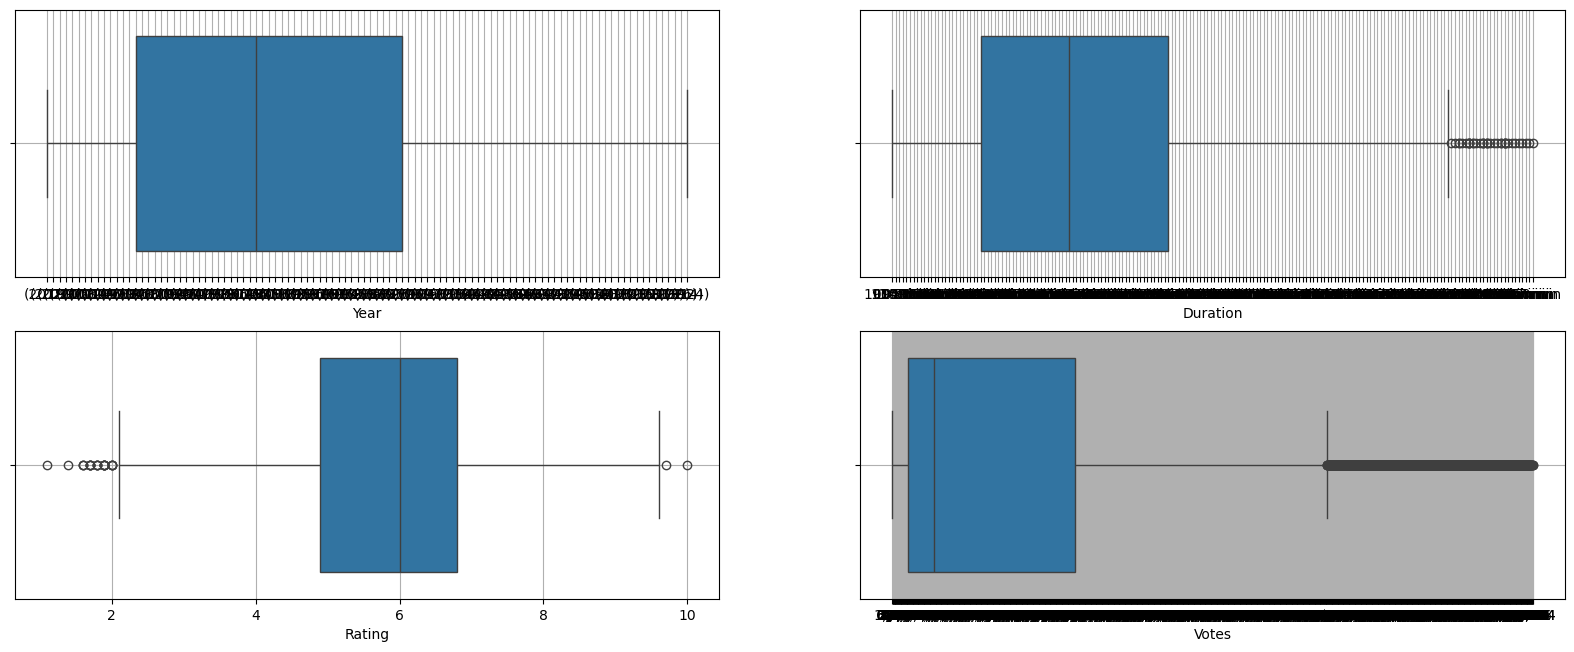

In [5]:
plt.figure(figsize=(20,16))

plt.subplot(4,2,1)
sb.boxplot(x=df['Year'])
plt.grid()

plt.subplot(4,2,2)
sb.boxplot(x=df['Duration'])
plt.grid()

plt.subplot(4,2,3)
sb.boxplot(x=df['Rating'])
plt.grid()

plt.subplot(4,2,4)
sb.boxplot(x=df['Votes'])
plt.grid()

In [106]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3', 'Primary_Genre'],
      dtype='object')

In [107]:
winsor_both = {
  
        Winsorizer(capping_method= 'quantiles', tail='both',fold = 0.05, variables=['Duration', 'Rating'])
     
}


- Winsorization effectively minimized the influence of extreme observations without losing valuable information.
- This improved the reliability of statistical analysis and prepared the dataset for machine learning models.
    - Identified extreme values in Duration and Rating columns
    - Applied Winsorization (5% quantile capping) on both tails
    - Reduced impact of unusually high and low observations
    - Preserved dataset size by avoiding row deletion

In [108]:
df['Votes_log'] = np.log1p(df['Votes'])

- The objective of this project was to preprocess the IMDb Indian Movies dataset and stabilize highly skewed numerical features for meaningful analysis and modeling.
    - Applied logarithmic transformation using log1p
    - Reduced skewness of vote distribution
    - Preserved relative popularity differences
    - Improved suitability for machine learning algorithms

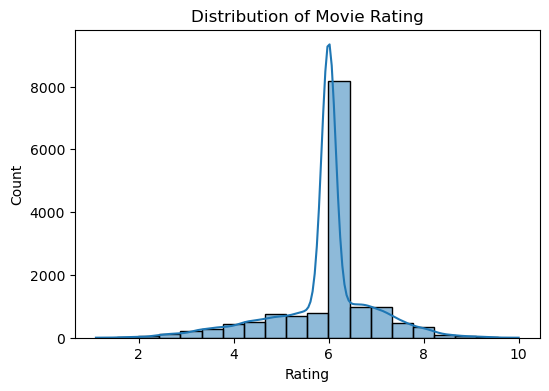

In [109]:
plt.figure(figsize=(6,4))
sb.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Rating")
plt.show()

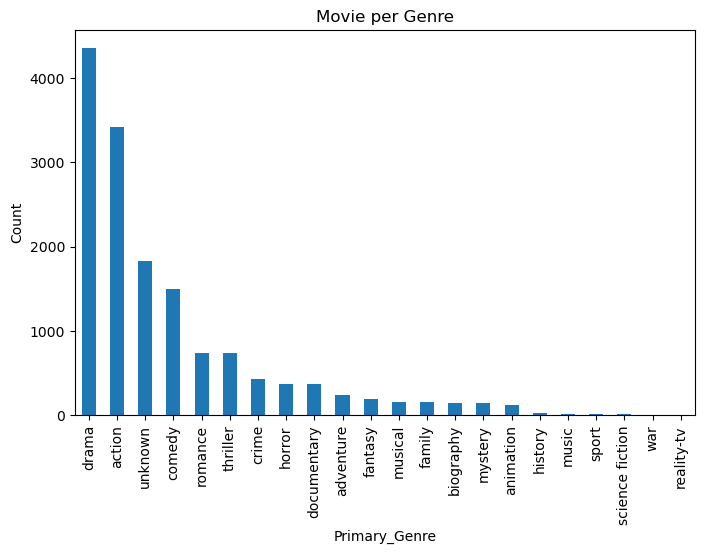

In [110]:
plt.figure(figsize=(8,5))
df['Primary_Genre'].value_counts().plot(kind='bar')
plt.title("Movie per Genre")
plt.ylabel("Count")
plt.show()

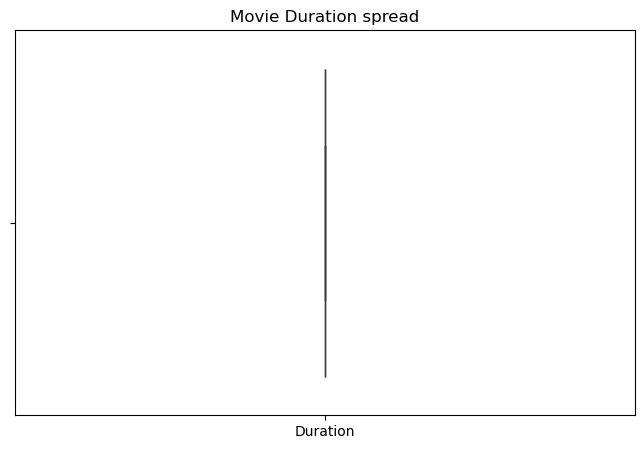

In [111]:
plt.figure(figsize=(8,5))
sb.boxplot(x=['Duration'])
plt.title("Movie Duration spread")
plt.show()

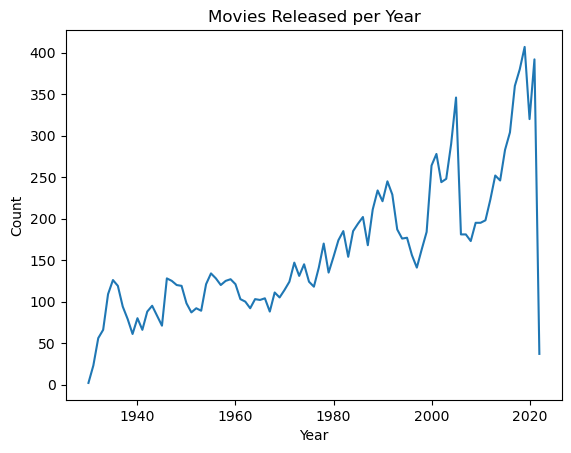

In [112]:
df['Year'].value_counts().sort_index().plot()
plt.title("Movies Released per Year")
plt.ylabel("Count")
plt.show()

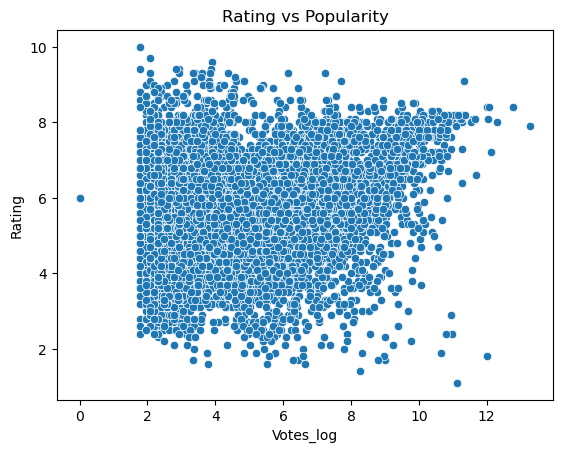

In [113]:
sb.scatterplot(x=df['Votes_log'], y=df['Rating'])
plt.title("Rating vs Popularity")
plt.show()

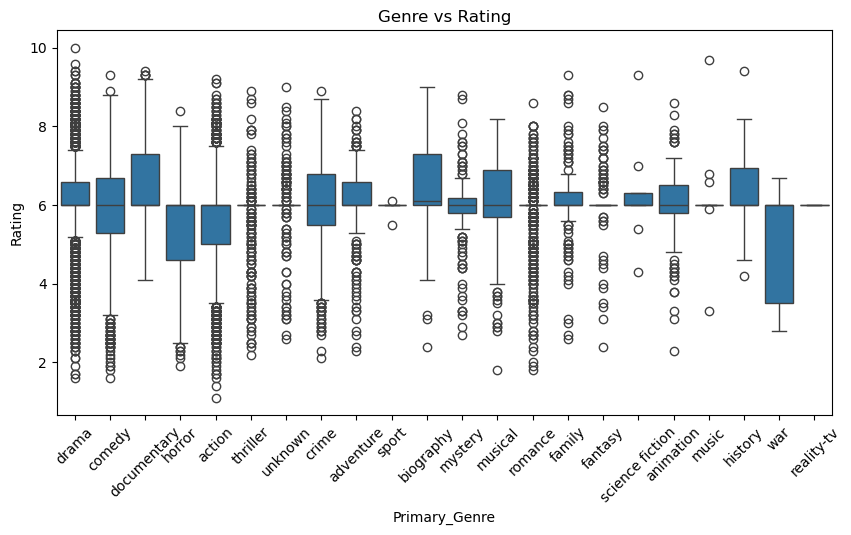

In [114]:
plt.figure(figsize=(10,5))
sb.boxplot(x=df['Primary_Genre'], y=df['Rating'], data= df)
plt.title("Genre vs Rating")
plt.xticks(rotation=45)
plt.show()

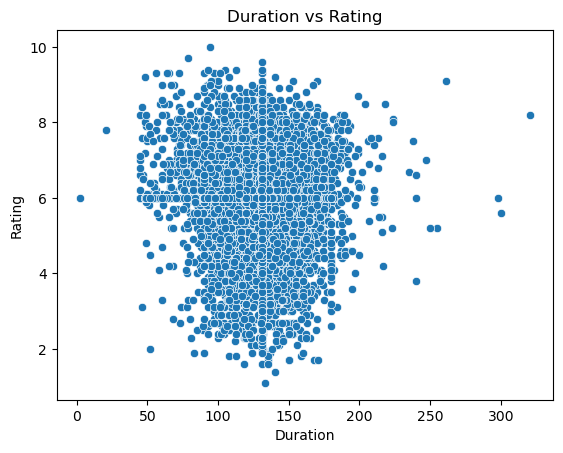

In [115]:
sb.scatterplot(x='Duration', y='Rating', data=df)
plt.title("Duration vs Rating")
plt.show()

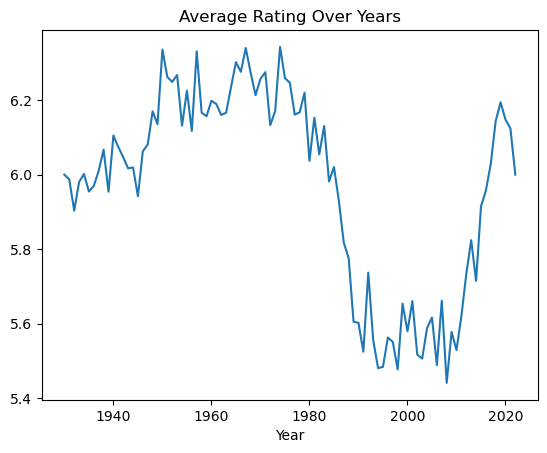

In [116]:
df.groupby('Year')['Rating'].mean().plot()
plt.title("Average Rating Over Years")
plt.show()

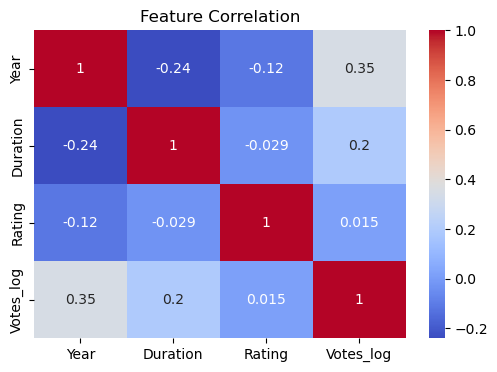

In [117]:
plt.figure(figsize=(6,4))
sb.heatmap(df[['Year','Duration','Rating','Votes_log']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

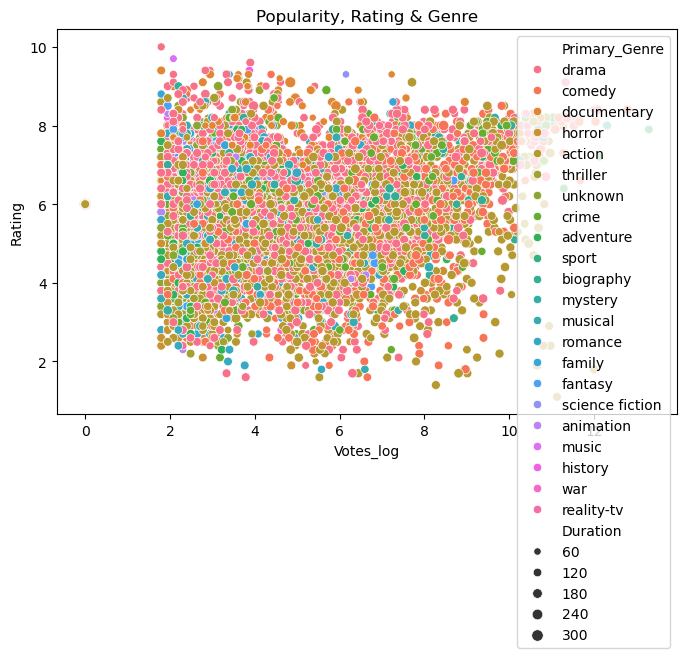

In [118]:
plt.figure(figsize=(8,5))
sb.scatterplot(x='Votes_log', y='Rating', hue='Primary_Genre', size='Duration', data=df)
plt.title("Popularity, Rating & Genre")
plt.show()

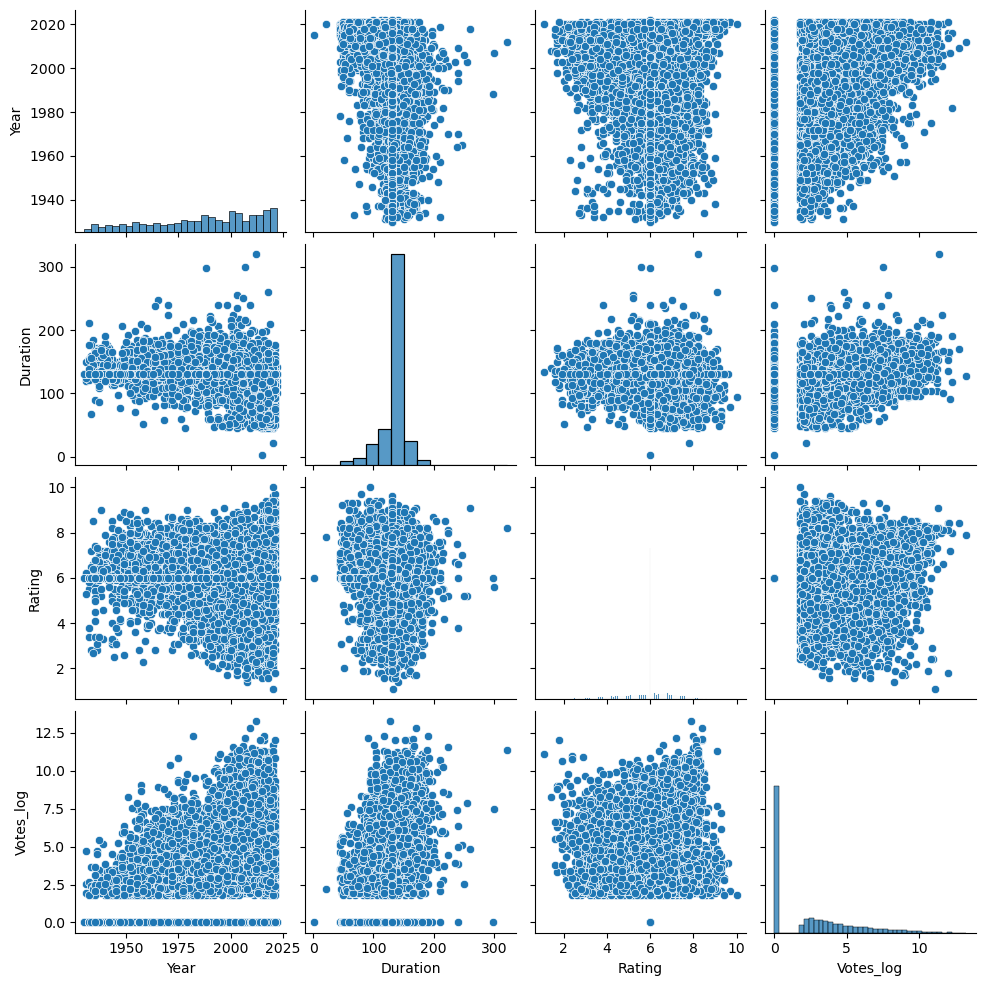

In [119]:
sb.pairplot(df[['Year','Duration','Rating','Votes_log']])
plt.show()

In [120]:
le = LabelEncoder()
cat_cols = ['Primary_Genre','Director','Actor 1','Actor 2','Actor 3']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [121]:
X = df[['Primary_Genre','Director','Actor 1','Actor 2','Actor 3',
        'Duration','Year','Votes_log']]
y = df['Rating']

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [123]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [124]:
y_pred = model.predict(X_test)

In [125]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.44135133779264213
RMSE: 0.8004929021367007
R2 Score: 0.3606812613972097


- The regression model achieved an MAE of 0.44 and RMSE of 0.80, indicating that predicted ratings are generally close to actual ratings with minor deviations. The R² score of 0.36 suggests that the model explains a moderate portion of rating variability. Since movie ratings are influenced by subjective human preferences and factors not present in the dataset, achieving extremely high accuracy is not expected. The model successfully captures meaningful patterns between movie features and ratings and can be used as a baseline rating prediction system.

<Axes: >

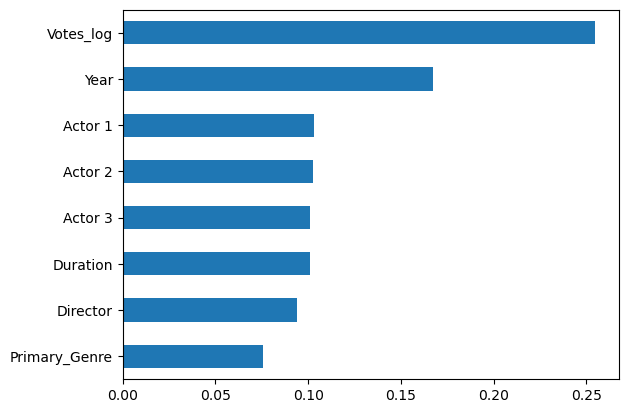

In [126]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')